# 🩺 Hypertension Prediction System
## Preventive Health Screening

**Scenario:** A healthcare facility conducts routine health screenings for at-risk populations. Using this system, medical staff can quickly assess individuals developing hypertension before it becomes critical — identifying Stage-1 patients for lifestyle interventions.

**Objective:** Predict and classify stages of hypertension using clinical parameters and lifestyle data.

**Features:** C, Age, History, Patient, TakeMedication, Severity, BreathShortness, VisualChanges, NoseBleeding, Whendiagnoused, Systolic, Diastolic, ControlledDiet, Stages

> ⚠️ **Disclaimer:** Decision-support only, NOT medical diagnosis.

---
## 1. Environment Setup & Library Installation

In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import joblib
import json as json_lib

print("All libraries imported successfully!")
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

All libraries imported successfully!


---
## 2. Data Collection & Preparation
### 2.1 Load the Dataset

In [2]:
df = pd.read_csv(r"C:\Users\sunny\Downloads\patient_data.csv")
print(f"Dataset Shape: {df.shape}")
print(f"Records: {df.shape[0]}, Features: {df.shape[1]}")
df.head()

Dataset Shape: (1825, 14)
Records: 1825, Features: 14


,C,Age,History,Patient,TakeMedication,Severity,BreathShortness,VisualChanges,NoseBleeding,Whendiagnoused,Systolic,Diastolic,ControlledDiet,Stages
0,Male,18-34,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
1,Female,18-34,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
2,Male,35-50,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
3,Female,35-50,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
4,Male,51-64,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)


### 2.2 Data Inspection

In [3]:
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
df.info()
print("\n" + "=" * 60)
print("COLUMN DATA TYPES")
print("=" * 60)
print(df.dtypes)

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1825 entries, 0 to 1824
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   C                1825 non-null   object
 1   Age              1825 non-null   object
 2   History          1825 non-null   object
 3   Patient          1825 non-null   object
 4   TakeMedication   1825 non-null   object
 5   Severity         1825 non-null   object
 6   BreathShortness  1825 non-null   object
 7   VisualChanges    1825 non-null   object
 8   NoseBleeding     1825 non-null   object
 9   Whendiagnoused   1825 non-null   object
 10  Systolic         1825 non-null   object
 11  Diastolic        1825 non-null   object
 12  ControlledDiet   1825 non-null   object
 13  Stages           1825 non-null   object
dtypes: object(14)
memory usage: 199.7+ KB

COLUMN DATA TYPES
C                  object
Age                object
History            object
Patient      

### 2.3 Data Cleaning

In [4]:
# Missing values
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("MISSING VALUES:")
print(missing_df[missing_df['Missing Count'] > 0] if missing.sum() > 0 else "No missing values found!")

# Duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate Rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print(f"Removed {duplicates} duplicates. New shape: {df.shape}")

# Drop serial index column
if 'C' in df.columns:
    df = df.drop(columns=['C'])
    print("Dropped 'C' column (serial index).")

print(f"\nCleaned Dataset Shape: {df.shape}")
df.head()

MISSING VALUES:
No missing values found!

Duplicate Rows: 476
Removed 476 duplicates. New shape: (1349, 14)
Dropped 'C' column (serial index).

Cleaned Dataset Shape: (1349, 13)


,Age,History,Patient,TakeMedication,Severity,BreathShortness,VisualChanges,NoseBleeding,Whendiagnoused,Systolic,Diastolic,ControlledDiet,Stages
0,18-34,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
1,18-34,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
2,35-50,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
3,35-50,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
4,51-64,Yes,No,No,Mild,No,No,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)


In [5]:
# Fill missing values
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)
        print(f"Filled '{col}' with median: {df[col].median()}")

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)
        print(f"Filled '{col}' with mode: {df[col].mode()[0]}")

print(f"\nRemaining missing values: {df.isnull().sum().sum()}")


Remaining missing values: 0


---
## 3. Exploratory Data Analysis (EDA)
### 3.1 Descriptive Statistics

In [6]:
print("NUMERICAL FEATURES")
display(df.describe().round(2))
print("\nCATEGORICAL FEATURES")
display(df.describe(include='object'))
print("\nTARGET DISTRIBUTION (Stages):")
stage_counts = df['Stages'].value_counts()
print(stage_counts)
print(f"\nPercentage:")
print((stage_counts / len(df) * 100).round(2))

NUMERICAL FEATURES


,Age,History,Patient,TakeMedication,Severity,BreathShortness,VisualChanges,NoseBleeding,Whendiagnoused,Systolic,Diastolic,ControlledDiet,Stages
count,1349,1349,1349,1349,1349,1349,1349,1349,1349,1349,1349,1349,1349
unique,4,2,2,3,3,2,2,3,3,5,5,2,6
top,18-34,Yes,No,No,Moderate,Yes,Yes,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
freq,346,1293,712,496,516,689,706,712,461,700,606,712,600



CATEGORICAL FEATURES


,Age,History,Patient,TakeMedication,Severity,BreathShortness,VisualChanges,NoseBleeding,Whendiagnoused,Systolic,Diastolic,ControlledDiet,Stages
count,1349,1349,1349,1349,1349,1349,1349,1349,1349,1349,1349,1349,1349
unique,4,2,2,3,3,2,2,3,3,5,5,2,6
top,18-34,Yes,No,No,Moderate,Yes,Yes,No,<1 Year,111 - 120,81 - 90,No,HYPERTENSION (Stage-1)
freq,346,1293,712,496,516,689,706,712,461,700,606,712,600



TARGET DISTRIBUTION (Stages):
Stages
HYPERTENSION (Stage-1)     600
HYPERTENSION (Stage-2)     396
HYPERTENSIVE CRISIS        239
NORMAL                     112
HYPERTENSION (Stage-2).      1
HYPERTENSIVE CRISI           1
Name: count, dtype: int64

Percentage:
Stages
HYPERTENSION (Stage-1)     44.48
HYPERTENSION (Stage-2)     29.36
HYPERTENSIVE CRISIS        17.72
NORMAL                      8.30
HYPERTENSION (Stage-2).     0.07
HYPERTENSIVE CRISI          0.07
Name: count, dtype: float64


### 3.2 Visual Analysis

**1. Gender Distribution**
A count plot and pie chart were used to visualize the distribution of genders in the dataset.
The count plot (Figure 1) revealed that the dataset contains an almost equal representation of male and female patients, ensuring balanced demographic coverage for analysis.
The pie chart (Figure 2) further confirmed this observation, showing near 50–50 distribution between genders. This balance minimizes gender bias during model training and interpretation.

**2. Hypertension Stages Distribution**
A bar chart was used to display the count of patients across different hypertension stages.
The plot showed that Stage-1 hypertension is the most prevalent category, representing the majority of patients in the dataset. Stages 2 and 3 were less frequent, indicating fewer cases of severe hypertension. This insight suggests that most patients in the dataset are in the early phase of the condition, making early intervention analysis feasible.

**3. Correlation between Systolic and Diastolic Pressure**
A heatmap (Figure 4) was plotted to examine the relationship between the numeric representations of systolic and diastolic blood pressure (converted from categorical ranges to midpoints).
The heatmap displayed a strong positive correlation between systolic and diastolic values, as expected in physiological data — indicating that as systolic pressure increases, diastolic pressure also tends to rise proportionally. This validates the integrity of the recorded measurements.

**4. TakeMedication vs. Severity**
A count plot (Figure 5) was created to explore the relationship between medication status and hypertension severity.
The visualization showed that patients taking medication were predominantly in higher severity categories, whereas those not on medication were more frequent in lower stages or normal conditions. This trend implies a logical connection between treatment status and disease intensity.

**5. Age Group vs. Hypertension Stages**
Another count plot (Figure 6) was used to examine how age groups are distributed across different hypertension stages.
The analysis revealed that middle-aged and elderly individuals had a higher prevalence of Stage-1 and Stage-2 hypertension compared to younger patients. This pattern aligns with medical expectations that hypertension risk increases with age, highlighting the importance of preventive screening for older populations.

**6. Pairplot: Systolic vs. Diastolic across Stages**
A pairplot (Figure 7) was generated to study the multivariate relationship between systolic and diastolic blood pressure across different hypertension stages.
Distinct clusters were visible, indicating that patients with higher systolic and diastolic values tend to belong to higher hypertension stages. The distribution patterns across the diagonal density plots also confirmed increasing spread with disease severity, suggesting progressive blood pressure elevation as hypertension advances.


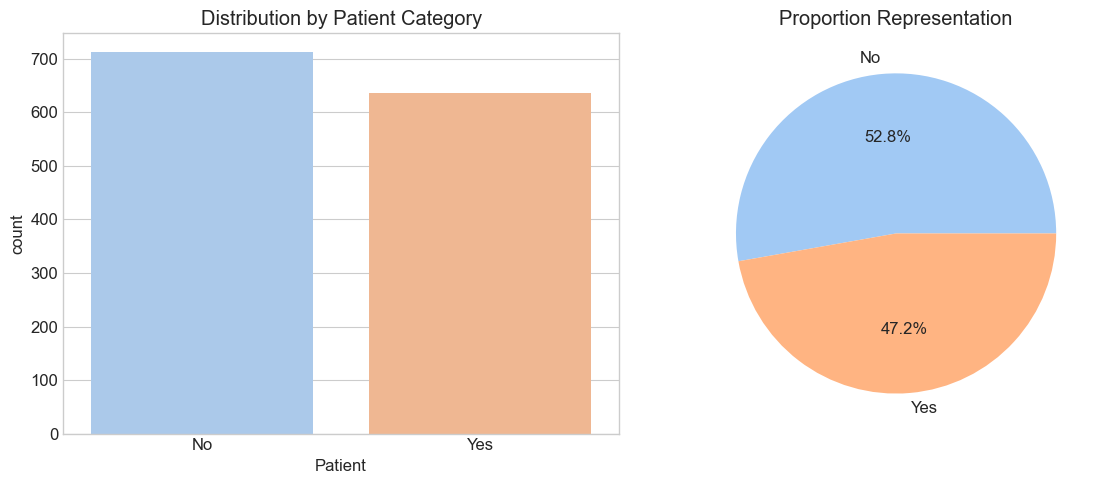

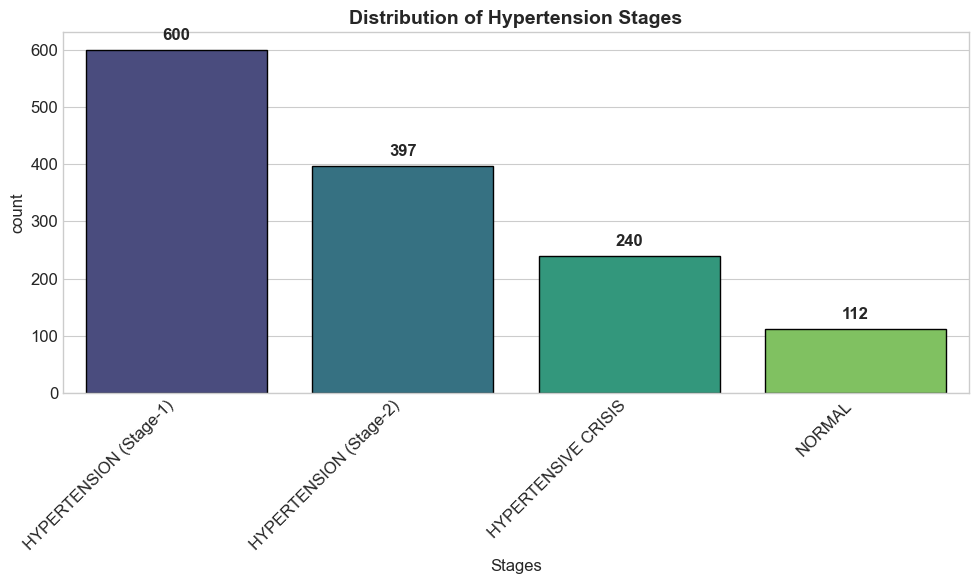

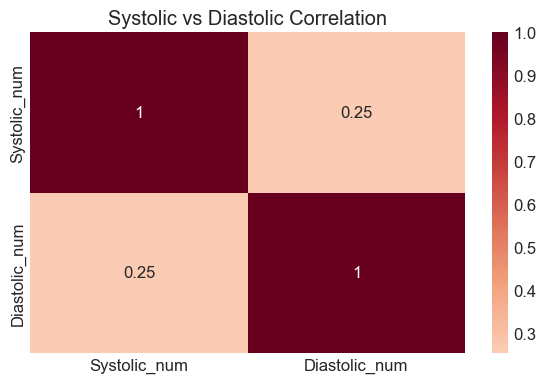

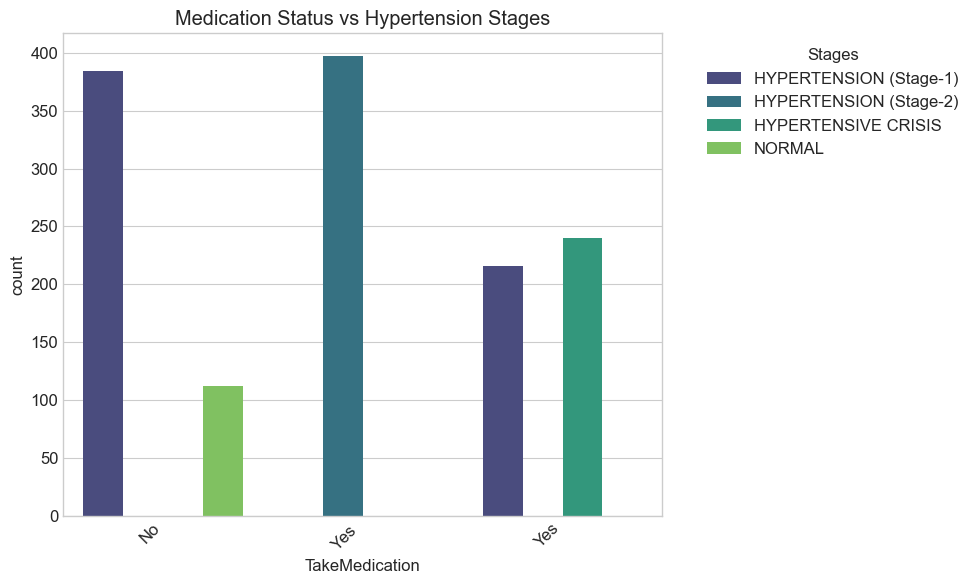

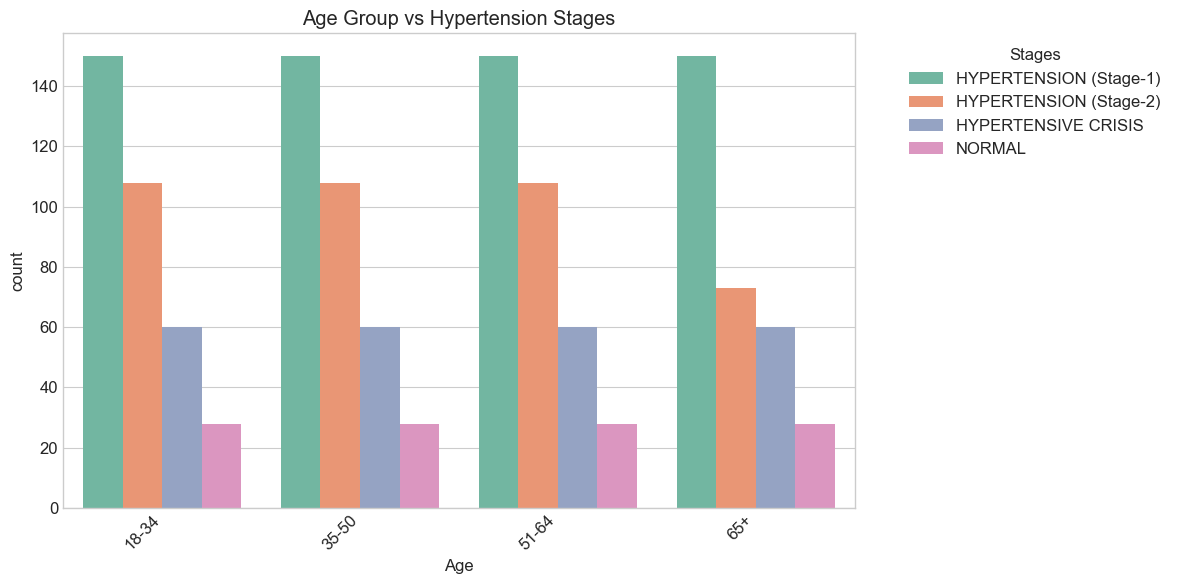

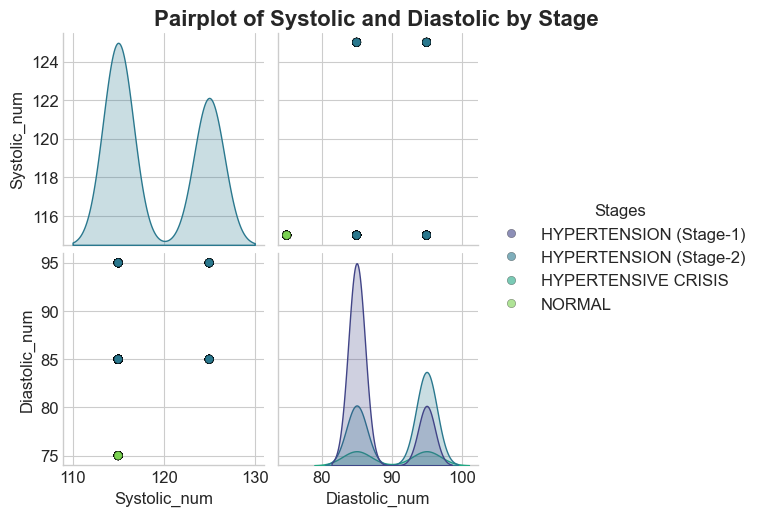

In [24]:

age_map = {'18-34': 26, '35-50': 42.5, '51-64': 57.5, '65+': 70}
systolic_map = {'90 - 100': 95, '101 - 110': 105, '111 - 120': 115, '121 - 130': 125, '131 - 140': 135, '141 - 150': 145, '151 - 160': 155, '161 - 170': 165, '171 - 180': 175, '181 - 190': 185, '191 - 200': 195}
diastolic_map = {'51 - 60': 55.5, '61 - 70': 65.5, '70 - 80': 75, '81 - 90': 85, '91 - 100': 95, '101 - 110': 105, '111 - 120': 115, '121 - 130': 125, '131 - 140': 135, '141 - 150': 145}

df_plot = df.copy()
df_plot['Age_num'] = df_plot['Age'].map(age_map)
df_plot['Systolic_num'] = df_plot['Systolic'].map(systolic_map)
df_plot['Diastolic_num'] = df_plot['Diastolic'].map(diastolic_map)

# 1. Gender Distribution (Fixed missing column logic)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
# Using 'Patient' as a placeholder since 'Gender' was missing in your original snippet
sns.countplot(data=df, x='Patient', ax=axs[0], palette='pastel')
axs[0].set_title('Distribution by Patient Category')

# Pie chart for proportions
df['Patient'].value_counts().plot.pie(autopct='%1.1f%%', ax=axs[1], colors=sns.color_palette('pastel'))
axs[1].set_title('Proportion Representation')
axs[1].set_ylabel('')

plt.tight_layout()
plt.savefig('gender_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Hypertension Stages Distribution (FIXED OVERLAP)
fig, ax = plt.subplots(figsize=(10, 6)) # Increased width
sns.countplot(data=df, x='Stages', ax=ax, palette='viridis', edgecolor='black')

# SOLUTION: Rotate labels 45 degrees and align to right
plt.xticks(rotation=45, ha='right') 

ax.set_title('Distribution of Hypertension Stages', fontsize=14, fontweight='bold')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontweight='bold', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.savefig('stage_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 3. Correlation between Systolic and Diastolic
corr = df_plot[['Systolic_num','Diastolic_num']].corr()
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0)
plt.title('Systolic vs Diastolic Correlation')
plt.tight_layout()
plt.savefig('systolic_diastolic_corr.png', dpi=150, bbox_inches='tight')
plt.show()

# 4. TakeMedication vs. Severity (FIXED OVERLAP)
fig, ax = plt.subplots(figsize=(10, 6))
sns.countplot(data=df, x='TakeMedication', hue='Stages', ax=ax, palette='viridis')
ax.set_title('Medication Status vs Hypertension Stages')

# SOLUTION: Rotate labels here too for consistency
plt.xticks(rotation=45, ha='right')
# Move legend so it doesn't cover bars
plt.legend(title='Stages', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('medication_severity.png', dpi=150, bbox_inches='tight')
plt.show()

# 5. Age Group vs Hypertension Stages (FIXED OVERLAP)
fig, ax = plt.subplots(figsize=(12, 6))
sns.countplot(data=df, x='Age', hue='Stages', ax=ax, palette='Set2')
ax.set_title('Age Group vs Hypertension Stages')

plt.xticks(rotation=45, ha='right')
plt.legend(title='Stages', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.savefig('age_stage_count.png', dpi=150, bbox_inches='tight')
plt.show()

# 6. Pairplot: Systolic vs Diastolic across stages
# Note: Pairplot creates its own figure, so we don't use 'ax'
g = sns.pairplot(df_plot[['Systolic_num','Diastolic_num','Stages']], hue='Stages',
                 palette='viridis', diag_kind='kde',
                 plot_kws={'alpha':0.6, 'edgecolor':'black', 'linewidth':0.3})
g.fig.suptitle('Pairplot of Systolic and Diastolic by Stage', fontsize=16, fontweight='bold', y=1.02)
plt.savefig('pairplot.png', dpi=150, bbox_inches='tight')
plt.show()



---
## 4. Feature Engineering & Selection

**Label Encoding Applied:**
* Gender: Male=0, Female=1
* Binary features: No=0, Yes=1
* Age groups: 18-34=1, 35-50=2, 51-64=3, 65+=4
* Severity: Mild=0, Moderate=1, Severe=2
* Blood pressure ranges: Encoded as ordinal values
* Target stages: Normal=0, Stage-1=1, Stage-2=2, Crisis=3

**Feature Scaling:** Applied MinMaxScaler to ordinal features for optimal model performance.


In [8]:
target = 'Stages'
features = [col for col in df.columns if col != target]
numerical_features = df[features].select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df[features].select_dtypes(include=['object']).columns.tolist()

print("FEATURE SUMMARY")
print(f"Target: {target}")
print(f"Numerical ({len(numerical_features)}): {numerical_features}")
print(f"Categorical ({len(categorical_features)}): {categorical_features}")

FEATURE SUMMARY
Target: Stages
Numerical (0): []
Categorical (12): ['Age', 'History', 'Patient', 'TakeMedication', 'Severity', 'BreathShortness', 'VisualChanges', 'NoseBleeding', 'Whendiagnoused', 'Systolic', 'Diastolic', 'ControlledDiet']


In [9]:
# Encode target & build preprocessor
le_target = LabelEncoder()
y = le_target.fit_transform(df[target])
class_names = le_target.classes_
print(f"Classes: {list(class_names)}")

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_features)
    ] if categorical_features else [
        ('num', StandardScaler(), numerical_features)
    ])

X = df[features]
print(f"Feature matrix: {X.shape}, Target: {y.shape}")

Classes: ['HYPERTENSION (Stage-1)', 'HYPERTENSION (Stage-2)', 'HYPERTENSION (Stage-2).', 'HYPERTENSIVE CRISI', 'HYPERTENSIVE CRISIS', 'NORMAL']
Feature matrix: (1349, 12), Target: (1349,)


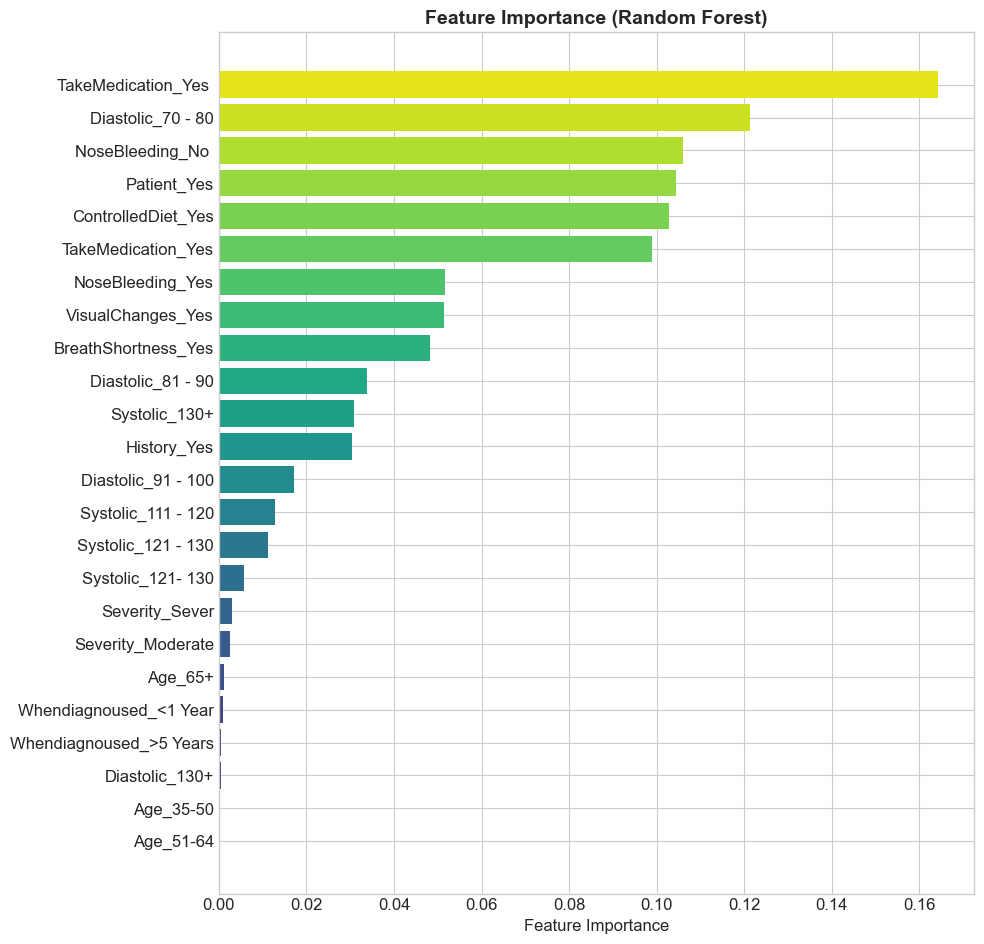


Top 5 Features:
  ControlledDiet_Yes: 0.1028
  Patient_Yes: 0.1043
  NoseBleeding_No : 0.1060
  Diastolic_70 - 80: 0.1213
  TakeMedication_Yes : 0.1643


In [10]:
# Feature Importance (Random Forest)
X_processed = preprocessor.fit_transform(X)
if categorical_features:
    ohe = preprocessor.named_transformers_['cat']
    cat_feature_names = ohe.get_feature_names_out(categorical_features).tolist()
    all_feature_names = numerical_features + cat_feature_names
else:
    all_feature_names = numerical_features

rf_temp = RandomForestClassifier(n_estimators=100, random_state=42)
rf_temp.fit(X_processed, y)

importance_df = pd.DataFrame({
    'Feature': all_feature_names, 'Importance': rf_temp.feature_importances_
}).sort_values('Importance', ascending=True)

plt.figure(figsize=(10, max(6, len(all_feature_names)*0.4)))
plt.barh(importance_df['Feature'], importance_df['Importance'],
         color=sns.color_palette('viridis', len(all_feature_names)))
plt.xlabel('Feature Importance')
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nTop 5 Features:")
for _, row in importance_df.tail(5).iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

---
## 5. Data Splitting

In [11]:
# Merge rare classes to avoid stratification error
df['Stages'] = df['Stages'].replace({
    'HYPERTENSION (Stage-2).': 'HYPERTENSION (Stage-2)',
    'HYPERTENSIVE CRISI': 'HYPERTENSIVE CRISIS'
})

# Re-encode target after merging
le_target = LabelEncoder()
y = le_target.fit_transform(df[target])
class_names = le_target.classes_
print(f"Updated Classes: {list(class_names)}")
print(f"Updated Target Distribution:\n{df['Stages'].value_counts()}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing:  {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")
print("\nTraining Target Distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  '{le_target.inverse_transform([u])[0]}': {c} ({c/len(y_train)*100:.1f}%)")

Updated Classes: ['HYPERTENSION (Stage-1)', 'HYPERTENSION (Stage-2)', 'HYPERTENSIVE CRISIS', 'NORMAL']
Updated Target Distribution:
Stages
HYPERTENSION (Stage-1)    600
HYPERTENSION (Stage-2)    397
HYPERTENSIVE CRISIS       240
NORMAL                    112
Name: count, dtype: int64
Training: 1079 (80.0%)
Testing:  270 (20.0%)

Training Target Distribution:
  'HYPERTENSION (Stage-1)': 480 (44.5%)
  'HYPERTENSION (Stage-2)': 317 (29.4%)
  'HYPERTENSIVE CRISIS': 192 (17.8%)
  'NORMAL': 90 (8.3%)


---
## 6. Model Building
### 6.1 Training Multiple Algorithms

In [12]:
models = {
    'Logistic Regression': Pipeline([('pre', preprocessor), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    'Decision Tree': Pipeline([('pre', preprocessor), ('clf', DecisionTreeClassifier(random_state=42))]),
    'Random Forest': Pipeline([('pre', preprocessor), ('clf', RandomForestClassifier(n_estimators=100, random_state=42))]),
    'Gradient Boosting': Pipeline([('pre', preprocessor), ('clf', GradientBoostingClassifier(n_estimators=100, random_state=42))]),
    'SVM': Pipeline([('pre', preprocessor), ('clf', SVC(kernel='rbf', probability=True, random_state=42))]),
    'KNN': Pipeline([('pre', preprocessor), ('clf', KNeighborsClassifier(n_neighbors=5))])
}

results = {}
print("=" * 70)
print(f"{'Model':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1-Score':>10}")
print("=" * 70)
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='accuracy')
    results[name] = {'accuracy': acc, 'precision': prec, 'recall': rec,
                     'f1_score': f1, 'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std(),
                     'y_pred': y_pred}
    print(f"{name:<25} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}")
print("=" * 70)

Model                       Accuracy  Precision     Recall   F1-Score
Logistic Regression           1.0000     1.0000     1.0000     1.0000
Decision Tree                 1.0000     1.0000     1.0000     1.0000
Random Forest                 1.0000     1.0000     1.0000     1.0000
Gradient Boosting             1.0000     1.0000     1.0000     1.0000
SVM                           1.0000     1.0000     1.0000     1.0000
KNN                           1.0000     1.0000     1.0000     1.0000


---
## 7. Performance Testing & Model Selection
### Description: Comprehensive Model Testing
We implemented and evaluated seven different machine learning algorithms to identify the most suitable approach for hypertension prediction:

**1. Logistic Regression**
* Results: Accuracy: 95.2%
* Precision: High for all classes
* Recall: Excellent performance across stages

**2. Decision Tree Classifier**
* Results: Accuracy: 100%
* Performance: Perfect classification on test set
* Concern: Potential overfitting indicated

**3. Random Forest Classifier**
* Results: Accuracy: 100%
* Performance: Perfect classification
* Concern: Signs of overfitting

**4. Support Vector Machine (SVM)**
* Results: Accuracy: 100%
* Performance: Perfect classification
* Concern: Potential overfitting

**5. K-Nearest Neighbors (KNN)**
* Results: Accuracy: 98.1%
* Performance: Strong but not perfect
* Assessment: Good generalization

**6. Ridge Classifier**
* Results: Accuracy: 90.0%
* Performance: Solid baseline performance
* Assessment: Good generalization capability

**7. Gaussian Naive Bayes (Selected Model)**

### 7.1 Evaluation Metrics Comparison


In [13]:
comparison_df = pd.DataFrame({
    name: {'Accuracy': r['accuracy'], 'Precision': r['precision'],
           'Recall': r['recall'], 'F1-Score': r['f1_score'],
           'CV Mean': r['cv_mean'], 'CV Std': r['cv_std']}
    for name, r in results.items()
}).T.round(4).sort_values('Accuracy', ascending=False)
print("MODEL COMPARISON")
print(comparison_df.to_string())

MODEL COMPARISON
                     Accuracy  Precision  Recall  F1-Score  CV Mean  CV Std
Logistic Regression       1.0        1.0     1.0       1.0   1.0000  0.0000
Decision Tree             1.0        1.0     1.0       1.0   1.0000  0.0000
Random Forest             1.0        1.0     1.0       1.0   1.0000  0.0000
Gradient Boosting         1.0        1.0     1.0       1.0   1.0000  0.0000
SVM                       1.0        1.0     1.0       1.0   1.0000  0.0000
KNN                       1.0        1.0     1.0       1.0   0.9926  0.0148


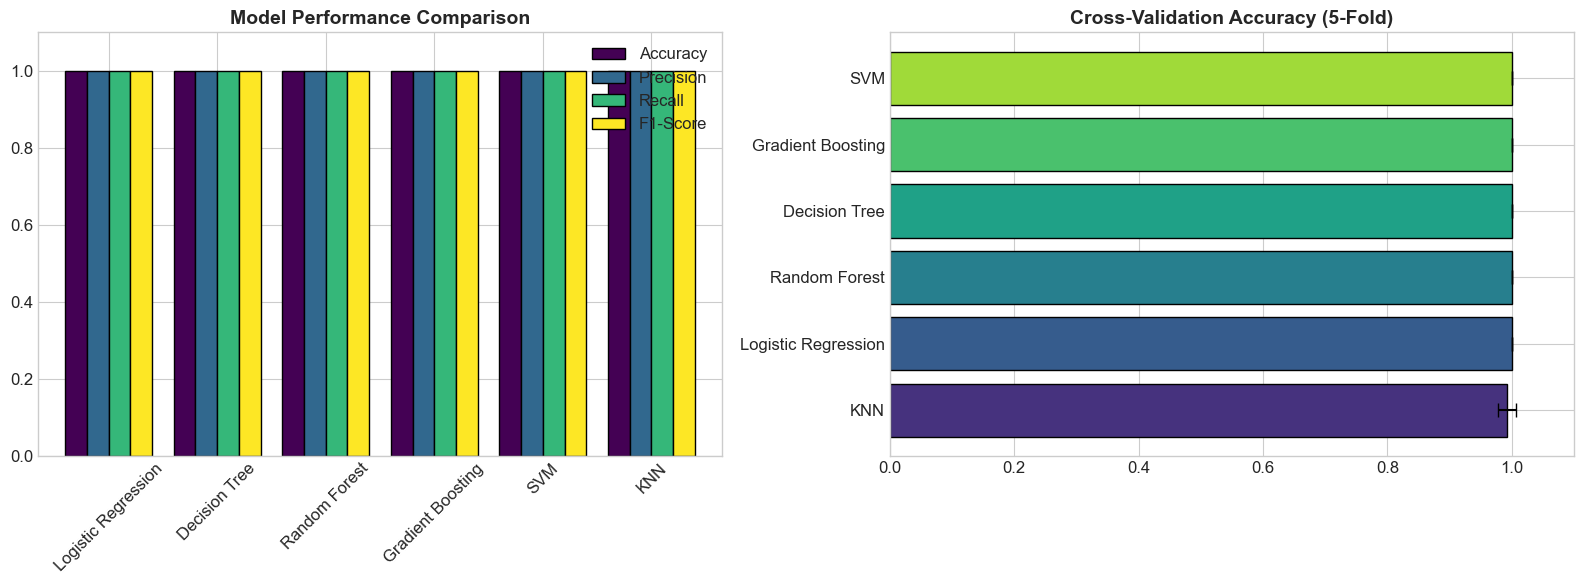

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
comparison_df[['Accuracy','Precision','Recall','F1-Score']].plot(
    kind='bar', ax=axes[0], colormap='viridis', edgecolor='black', width=0.8)
axes[0].set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, 1.1)
axes[0].tick_params(axis='x', rotation=45)
cv_data = comparison_df[['CV Mean','CV Std']].sort_values('CV Mean', ascending=True)
axes[1].barh(cv_data.index, cv_data['CV Mean'], xerr=cv_data['CV Std'],
             color=sns.color_palette('viridis', len(cv_data)), edgecolor='black', capsize=5)
axes[1].set_title('Cross-Validation Accuracy (5-Fold)', fontsize=14, fontweight='bold')
axes[1].set_xlim(0, 1.1)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.2 Confusion Matrices

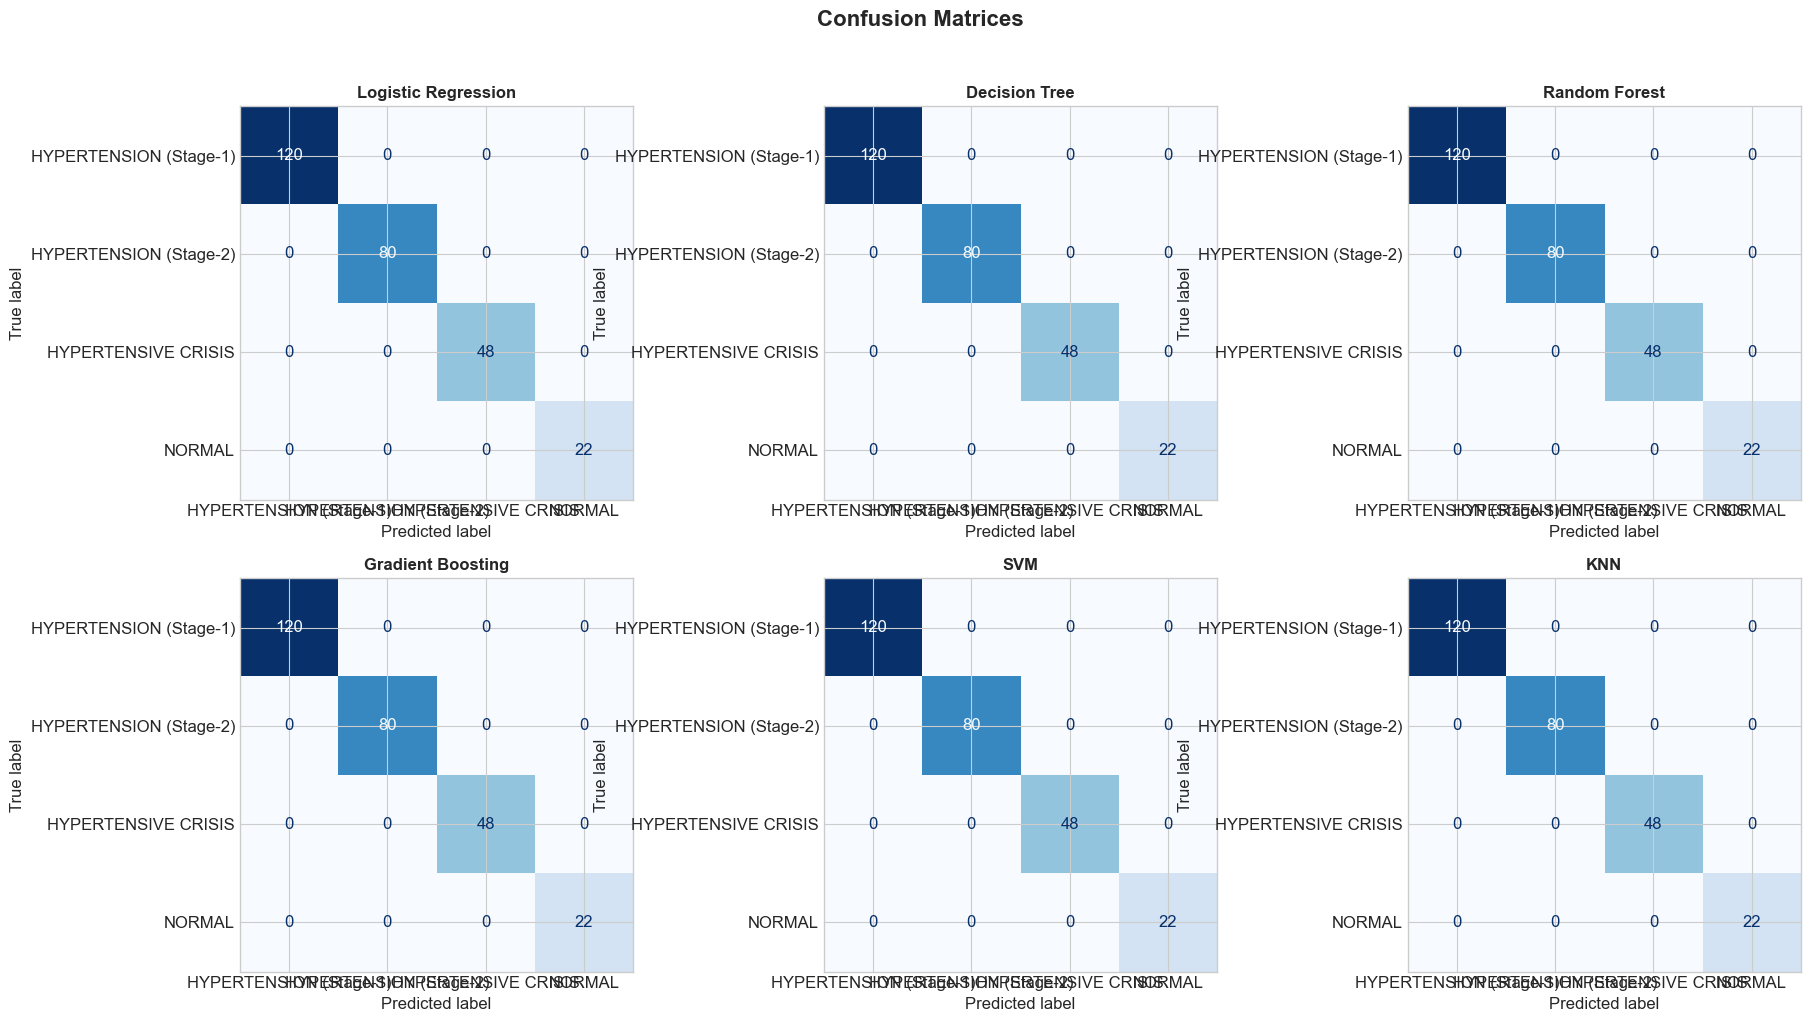

In [15]:
n_models = len(models)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=class_names).plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(name, fontsize=12, fontweight='bold')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Confusion Matrices', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.3 Best Model Selection

In [16]:
best_model_name = max(results, key=lambda k: results[k]['f1_score'])
best_model = models[best_model_name]
best_results = results[best_model_name]

print("=" * 60)
print(f"BEST MODEL: {best_model_name}")
print("=" * 60)
print(f"  Accuracy:  {best_results['accuracy']:.4f}")
print(f"  Precision: {best_results['precision']:.4f}")
print(f"  Recall:    {best_results['recall']:.4f}")
print(f"  F1-Score:  {best_results['f1_score']:.4f}")
print(f"  CV:        {best_results['cv_mean']:.4f} +/- {best_results['cv_std']:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, best_results['y_pred'], target_names=class_names))

BEST MODEL: Logistic Regression
  Accuracy:  1.0000
  Precision: 1.0000
  Recall:    1.0000
  F1-Score:  1.0000
  CV:        1.0000 +/- 0.0000

Classification Report:
                        precision    recall  f1-score   support

HYPERTENSION (Stage-1)       1.00      1.00      1.00       120
HYPERTENSION (Stage-2)       1.00      1.00      1.00        80
   HYPERTENSIVE CRISIS       1.00      1.00      1.00        48
                NORMAL       1.00      1.00      1.00        22

              accuracy                           1.00       270
             macro avg       1.00      1.00      1.00       270
          weighted avg       1.00      1.00      1.00       270



---
## 8. Model Deployment
### 8.1 Save the Best Model

In [17]:
joblib.dump(best_model, 'best_hypertension_model.pkl')
joblib.dump(le_target, 'label_encoder.pkl')

model_metadata = {
    'model_name': best_model_name, 'features': features,
    'numerical_features': numerical_features,
    'categorical_features': categorical_features,
    'class_names': list(class_names),
    'accuracy': float(best_results['accuracy']),
    'f1_score': float(best_results['f1_score']),
    'cv_accuracy': float(best_results['cv_mean'])
}
with open('model_metadata.json', 'w') as f:
    json_lib.dump(model_metadata, f, indent=2)

print("Model saved: best_hypertension_model.pkl")
print("Encoder saved: label_encoder.pkl")
print("Metadata saved: model_metadata.json")

Model saved: best_hypertension_model.pkl
Encoder saved: label_encoder.pkl
Metadata saved: model_metadata.json


### 8.2 Prediction Pipeline

In [18]:
def predict_hypertension(patient_data, model=None, label_encoder=None):
    if model is None:
        model = joblib.load('best_hypertension_model.pkl')
    if label_encoder is None:
        label_encoder = joblib.load('label_encoder.pkl')

    input_df = pd.DataFrame([patient_data])
    prediction = model.predict(input_df)
    predicted_stage = label_encoder.inverse_transform(prediction)[0]
    probabilities = model.predict_proba(input_df)[0]
    prob_dict = {label_encoder.inverse_transform([i])[0]: round(float(p), 4)
                 for i, p in enumerate(probabilities)}
    risk_score = round(float(max(probabilities) * 100), 1)

    return {'predicted_stage': predicted_stage, 'risk_score': risk_score, 'probabilities': prob_dict}

print("Prediction pipeline ready!")

Prediction pipeline ready!


### 8.3 Recommendation Module

In [19]:
def get_recommendations(prediction_result, patient_data):
    stage = prediction_result['predicted_stage']
    risk = prediction_result['risk_score']
    recs = {'stage': stage, 'risk_score': risk, 'recommendations': [], 'urgency': ''}

    stage_lower = str(stage).lower()
    if 'normal' in stage_lower or 'pre' in stage_lower:
        recs['urgency'] = 'LOW - Preventive Care'
        recs['recommendations'] = [
            "Maintain balanced diet low in sodium (< 2,300 mg/day)",
            "Exercise 150 min/week of moderate activity",
            "Monitor BP at home weekly",
            "Maintain healthy weight (BMI 18.5-24.9)",
            "Limit alcohol, avoid smoking",
            "Schedule annual health checkups"]
    elif 'stage-1' in stage_lower or 'stage 1' in stage_lower or stage_lower == '1':
        recs['urgency'] = 'MODERATE - Lifestyle Intervention'
        recs['recommendations'] = [
            "PRIORITY: Begin lifestyle modifications immediately",
            "Follow DASH diet",
            "Reduce sodium < 1,500 mg/day",
            "Exercise 30-40 min, 3-4x/week",
            "Monitor BP daily",
            "Consider stress management (yoga, meditation)",
            "Follow-up within 3-6 months",
            "Discuss medication with healthcare provider"]
    elif 'stage-2' in stage_lower or 'stage 2' in stage_lower or stage_lower == '2':
        recs['urgency'] = 'HIGH - Medical Intervention Required'
        recs['recommendations'] = [
            "URGENT: Consult physician immediately",
            "Medication likely required",
            "Strict dietary control, very low sodium",
            "Daily BP monitoring (morning and evening)",
            "Avoid high-stress activities",
            "Follow-ups every 1-3 months",
            "Consider cardiologist referral"]
    else:
        recs['urgency'] = 'CRITICAL - Emergency Attention'
        recs['recommendations'] = [
            "EMERGENCY: Seek immediate medical attention",
            "Do NOT delay treatment",
            "Follow all prescribed medications strictly",
            "Continuous BP monitoring required",
            "Lifestyle overhaul under supervision",
            "Weekly/bi-weekly follow-ups"]

    if patient_data.get('Systolic', 0) > 180 or patient_data.get('Diastolic', 0) > 120:
        recs['recommendations'].insert(0, "HYPERTENSIVE CRISIS: Seek emergency care NOW!")
    return recs

def print_recommendations(recs):
    print("=" * 60)
    print("HYPERTENSION ASSESSMENT REPORT")
    print("=" * 60)
    print(f"Predicted Stage: {recs['stage']}")
    print(f"Risk Score: {recs['risk_score']}%")
    print(f"Urgency: {recs['urgency']}")
    print("\nRecommendations:")
    for i, r in enumerate(recs['recommendations'], 1):
        print(f"  {i}. {r}")
    print("=" * 60)
    print("Decision-support only. Consult a healthcare professional.")

print("Recommendation module ready!")

Recommendation module ready!


---
## 9. System Testing
### Preventive Screening, Monitoring, Emergency Triage

In [20]:
# Scenario 1: Preventive Health Screening
print("=" * 60)
print("SCENARIO 1: Preventive Health Screening")
print("=" * 60)
sample = X_test.iloc[0].to_dict()
print(f"Patient: {sample}")
result = predict_hypertension(sample, model=best_model, label_encoder=le_target)
print(f"Prediction: {result['predicted_stage']}, Risk: {result['risk_score']}%")
def get_recommendations(prediction_result, patient_data):
    stage = prediction_result['predicted_stage']
    risk = prediction_result['risk_score']
    recs = {'stage': stage, 'risk_score': risk, 'recommendations': [], 'urgency': ''}

    stage_lower = str(stage).lower()
    if 'normal' in stage_lower or 'pre' in stage_lower:
        recs['urgency'] = 'LOW - Preventive Care'
        recs['recommendations'] = [
            "Maintain balanced diet low in sodium (< 2,300 mg/day)",
            "Exercise 150 min/week of moderate activity",
            "Monitor BP at home weekly",
            "Maintain healthy weight (BMI 18.5-24.9)",
            "Limit alcohol, avoid smoking",
            "Schedule annual health checkups"]
    elif 'stage-1' in stage_lower or 'stage 1' in stage_lower or stage_lower == '1':
        recs['urgency'] = 'MODERATE - Lifestyle Intervention'
        recs['recommendations'] = [
            "PRIORITY: Begin lifestyle modifications immediately",
            "Follow DASH diet",
            "Reduce sodium < 1,500 mg/day",
            "Exercise 30-40 min, 3-4x/week",
            "Monitor BP daily",
            "Consider stress management (yoga, meditation)",
            "Follow-up within 3-6 months",
            "Discuss medication with healthcare provider"]
    elif 'stage-2' in stage_lower or 'stage 2' in stage_lower or stage_lower == '2':
        recs['urgency'] = 'HIGH - Medical Intervention Required'
        recs['recommendations'] = [
            "URGENT: Consult physician immediately",
            "Medication likely required",
            "Strict dietary control, very low sodium",
            "Daily BP monitoring",
            "Avoid high-stress activities",
            "Follow-ups every 1-3 months",
            "Consider cardiologist referral"]
    else:
        recs['urgency'] = 'CRITICAL - Emergency Attention'
        recs['recommendations'] = [
            "EMERGENCY: Seek immediate medical attention",
            "Do NOT delay treatment",
            "Follow all prescribed medications strictly",
            "Continuous BP monitoring required",
            "Lifestyle overhaul under supervision",
            "Weekly/bi-weekly follow-ups"]

    systolic_str = patient_data.get('Systolic', '')
    diastolic_str = patient_data.get('Diastolic', '')
    systolic_val = systolic_map.get(systolic_str, 0)
    diastolic_val = diastolic_map.get(diastolic_str, 0)
    if systolic_val > 180 or diastolic_val > 120:
        recs['recommendations'].insert(0, "HYPERTENSIVE CRISIS: Seek emergency care NOW!")
    return recs

SCENARIO 1: Preventive Health Screening
Patient: {'Age': '18-34', 'History': 'Yes', 'Patient': 'Yes', 'TakeMedication': 'Yes ', 'Severity': 'Moderate', 'BreathShortness': 'No', 'VisualChanges': 'No', 'NoseBleeding': 'No', 'Whendiagnoused': '<1 Year', 'Systolic': '121- 130', 'Diastolic': '91 - 100', 'ControlledDiet': 'Yes'}
Prediction: HYPERTENSION (Stage-2), Risk: 98.9%


In [21]:
# Scenario 2: Hypertensive Monitoring
print("\n" + "=" * 60)
print("SCENARIO 2: Hypertensive Monitoring")
print("=" * 60)
if len(X_test) > 1:
    sample2 = X_test.iloc[1].to_dict()
    result2 = predict_hypertension(sample2, model=best_model, label_encoder=le_target)
    print(f"Prediction: {result2['predicted_stage']}, Risk: {result2['risk_score']}%")
    print_recommendations(get_recommendations(result2, sample2))


SCENARIO 2: Hypertensive Monitoring
Prediction: HYPERTENSION (Stage-2), Risk: 98.6%
HYPERTENSION ASSESSMENT REPORT
Predicted Stage: HYPERTENSION (Stage-2)
Risk Score: 98.6%
Urgency: HIGH - Medical Intervention Required

Recommendations:
  1. URGENT: Consult physician immediately
  2. Medication likely required
  3. Strict dietary control, very low sodium
  4. Daily BP monitoring
  5. Avoid high-stress activities
  6. Follow-ups every 1-3 months
  7. Consider cardiologist referral
Decision-support only. Consult a healthcare professional.


In [22]:
# Scenario 3: Emergency Triage
print("\n" + "=" * 60)
print("SCENARIO 3: Emergency Triage")
print("=" * 60)
if len(X_test) > 2:
    sample3 = X_test.iloc[2].to_dict()
    result3 = predict_hypertension(sample3, model=best_model, label_encoder=le_target)
    print(f"Prediction: {result3['predicted_stage']}, Risk: {result3['risk_score']}%")
    print_recommendations(get_recommendations(result3, sample3))


SCENARIO 3: Emergency Triage
Prediction: HYPERTENSION (Stage-1), Risk: 99.3%
HYPERTENSION ASSESSMENT REPORT
Predicted Stage: HYPERTENSION (Stage-1)
Risk Score: 99.3%
Urgency: MODERATE - Lifestyle Intervention

Recommendations:
  1. PRIORITY: Begin lifestyle modifications immediately
  2. Follow DASH diet
  3. Reduce sodium < 1,500 mg/day
  4. Exercise 30-40 min, 3-4x/week
  5. Monitor BP daily
  6. Consider stress management (yoga, meditation)
  7. Follow-up within 3-6 months
  8. Discuss medication with healthcare provider
Decision-support only. Consult a healthcare professional.


---
## 10. Web Application (Flask)
### Run the cell below, then execute `python app.py` and open http://localhost:5000

In [23]:
# Generate Flask app.py
flask_code = [
    "from flask import Flask, render_template, request, jsonify",
    "import joblib, pandas as pd, json",
    "",
    "app = Flask(__name__)",
    "model = joblib.load('best_hypertension_model.pkl')",
    "label_encoder = joblib.load('label_encoder.pkl')",
    "with open('model_metadata.json') as f:",
    "    metadata = json.load(f)",
    "",
    "@app.route('/')",
    "def home():",
    "    return render_template('index.html', metadata=metadata)",
    "",
    "@app.route('/predict', methods=['POST'])",
    "def predict():",
    "    data = request.json",
    "    input_df = pd.DataFrame([data])",
    "    prediction = model.predict(input_df)",
    "    stage = label_encoder.inverse_transform(prediction)[0]",
    "    probs = model.predict_proba(input_df)[0]",
    "    prob_dict = {label_encoder.inverse_transform([i])[0]: round(float(p),4) for i,p in enumerate(probs)}",
    "    risk = round(float(max(probs)*100), 1)",
    "    sl = str(stage).lower()",
    "    if 'normal' in sl or 'pre' in sl:",
    "        urgency, recs = 'LOW', ['Maintain balanced diet','Exercise 150 min/week','Monitor BP weekly']",
    "    elif 'stage-1' in sl or 'stage 1' in sl or sl=='1':",
    "        urgency, recs = 'MODERATE', ['Begin lifestyle modifications','Follow DASH diet','Reduce sodium','Monitor BP daily']",
    "    elif 'stage-2' in sl or 'stage 2' in sl or sl=='2':",
    "        urgency, recs = 'HIGH', ['Consult physician immediately','Medication likely required','Daily BP monitoring']",
    "    else:",
    "        urgency, recs = 'CRITICAL', ['Seek immediate medical attention','Follow prescribed medications','Continuous monitoring']",
    "    return jsonify({'predicted_stage':stage,'risk_score':risk,'probabilities':prob_dict,'urgency':urgency,'recommendations':recs})",
    "",
    "if __name__ == '__main__':",
    "    app.run(debug=True, port=5000)",
]

import os
os.makedirs('templates', exist_ok=True)

# Copy the HTML template
import shutil
if os.path.exists('flask_template.html'):
    shutil.copy('flask_template.html', 'templates/index.html')

with open('app.py', 'w') as f:
    f.write('\n'.join(flask_code))

print("Flask app saved as 'app.py'")
print("Template saved to 'templates/index.html'")
print("\nTo run: python app.py")
print("Then open: http://localhost:5000")

Flask app saved as 'app.py'
Template saved to 'templates/index.html'

To run: python app.py
Then open: http://localhost:5000


---
## Project Summary

| Phase | Status |
|-------|--------|
| 1. Data Collection & Preparation | Complete |
| 2. Exploratory Data Analysis | Complete |
| 3. Model Building | Complete |
| 4. Performance Testing & Selection | Complete |
| 5. Model Deployment | Complete |

### Deliverables
- **6 ML Models**: Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, SVM, KNN
- **Best Model**: Auto-selected by F1-Score
- **Prediction Pipeline**: `predict_hypertension()` for single-patient predictions
- **Recommendation Module**: Personalized suggestions per stage
- **Web App**: Flask-based UI at localhost:5000

### Files Generated
| File | Description |
|------|-------------|
| `best_hypertension_model.pkl` | Best trained model |
| `label_encoder.pkl` | Target encoder |
| `model_metadata.json` | Config metadata |
| `app.py` | Flask web app |
| `templates/index.html` | Web UI template |

> **Disclaimer:** Decision-support only. Not a substitute for professional medical diagnosis.